# Pandas Analyzer & Data Visualization

A menu-driven Sales Data Analysis and Visualization tool built with **Pandas**, **NumPy**, **Matplotlib**, and **Seaborn**, wrapped inside a single encapsulated `SalesDataAnalyzer` class.

Run the cells in order, then run the final cell to launch the interactive menu.

## Imports

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## `SalesDataAnalyzer` Class

In [2]:
class SalesDataAnalyzer:

    def __init__(self, file_path=None):
        self.data = None
        self._last_figure = None
        if file_path:
            self.load_data(file_path)

    def __del__(self):
        plt.close('all')

    def __len__(self):
        if self.data is None:
            return 0
        return len(self.data)

    def __add__(self, other):
        if not isinstance(other, SalesDataAnalyzer):
            return NotImplemented
        combined = SalesDataAnalyzer()
        combined.data = pd.concat([self.data, other.data], ignore_index=True)
        return combined

    def load_data(self, file_path):
        try:
            self.data = pd.read_csv(file_path)
            print("Dataset loaded successfully!")
        except FileNotFoundError:
            print(f"Error: File not found at '{file_path}'")
        except Exception as e:
            print(f"Error loading dataset: {e}")

    def explore_data(self):
        print("\n== Explore Data ==")
        if self.data is None:
            print("No dataset loaded. Please load a dataset first.")
            return
        print("1. Display the first 5 rows")
        print("2. Display the last 5 rows")
        print("3. Display column names")
        print("4. Display data types")
        print("5. Display basic info")
        choice = input("Enter your choice: ").strip()

        match choice:
            case '1':
                print()
                print(self.data.head())
            case '2':
                print()
                print(self.data.tail())
            case '3':
                print()
                print(list(self.data.columns))
            case '4':
                print()
                print(self.data.dtypes)
            case '5':
                print()
                self.data.info()
            case _:
                print("Invalid choice!")

    def dataframe_operations(self):
        print("\n== Perform DataFrame Operations ==")
        if self.data is None:
            print("No dataset loaded. Please load a dataset first.")
            return
        print("1. Convert Column to NumPy Array (Indexing & Slicing)")
        print("2. Mathematical Operations")
        print("3. Combine DataFrames")
        print("4. Split DataFrame")
        print("5. Search, Sort, or Filter Data")
        print("6. Create Pivot Table")
        choice = input("Enter your choice: ").strip()

        match choice:
            case '1':
                self._numpy_conversion()
            case '2':
                self.mathematical_operations()
            case '3':
                self.combine_data()
            case '4':
                self.split_data()
            case '5':
                self.search_sort_filter()
            case '6':
                self.create_pivot_table()
            case _:
                print("Invalid choice!")

    def _numpy_conversion(self):
        print("\n== Convert Column to NumPy Array ==")
        column = input("Enter the column name: ").strip()
        if column not in self.data.columns:
            print(f"Column '{column}' not found in the dataset.")
            return
        array = self.data[column].to_numpy()
        print("\nNumPy Array:")
        print(array)
        try:
            index = int(input("\nEnter an index to retrieve an element: "))
            print(f"Element at index {index}: {array[index]}")
        except (ValueError, IndexError):
            print("Invalid index entered!")
        rng = input("Enter a slice range (start:end): ").strip()
        try:
            start, end = map(int, rng.split(':'))
            print("Sliced Array:")
            print(array[start:end])
        except ValueError:
            print("Invalid slice range entered!")

    def mathematical_operations(self):
        print("\n== Mathematical Operations ==")
        col_a = input("Enter the first numeric column name: ").strip()
        col_b = input("Enter the second numeric column name: ").strip()
        if col_a not in self.data.columns or col_b not in self.data.columns:
            print("One or both columns not found in the dataset.")
            return
        array_a = self.data[col_a].to_numpy()
        array_b = self.data[col_b].to_numpy()

        print("Choose an operation:")
        print("1. Addition")
        print("2. Subtraction")
        print("3. Multiplication")
        print("4. Division")
        choice = input("Enter your choice: ").strip()

        match choice:
            case '1':
                print("\nResult of Addition:")
                print(array_a + array_b)
            case '2':
                print("\nResult of Subtraction:")
                print(array_a - array_b)
            case '3':
                print("\nResult of Multiplication:")
                print(array_a * array_b)
            case '4':
                print("\nResult of Division:")
                print(array_a / array_b)
            case _:
                print("Invalid choice!")

    def combine_data(self, other_dataframe=None):
        print("\n== Combine DataFrames ==")
        if other_dataframe is None:
            other_path = input("Enter the path of the CSV file to combine: ").strip()
            try:
                other_dataframe = pd.read_csv(other_path)
            except FileNotFoundError:
                print(f"Error: File not found at '{other_path}'")
                return
            except Exception as e:
                print(f"Error loading dataset: {e}")
                return

        print("Choose a combine method:")
        print("1. Concat (Stack Rows)")
        print("2. Merge (Join on a Common Column)")
        choice = input("Enter your choice: ").strip()

        match choice:
            case '1':
                self.data = pd.concat([self.data, other_dataframe], ignore_index=True)
                print("\nDataFrames combined using concat successfully!")
                print(self.data)
            case '2':
                key = input("Enter the common column name to merge on: ").strip()
                try:
                    self.data = pd.merge(self.data, other_dataframe, on=key)
                    print("\nDataFrames combined using merge successfully!")
                    print(self.data)
                except Exception as e:
                    print(f"Error merging datasets: {e}")
            case _:
                print("Invalid choice!")

    def split_data(self):
        print("\n== Split DataFrame ==")
        column = input("Enter the column name to split by: ").strip()
        if column not in self.data.columns:
            print(f"Column '{column}' not found in the dataset.")
            return
        groups = self.data.groupby(column)
        print(f"\nDataFrame split into {groups.ngroups} groups based on '{column}':")
        for key, group in groups:
            print(f"\nGroup: {key}")
            print(group)

    def search_sort_filter(self):
        print("\n== Search, Sort, or Filter Data ==")
        if self.data is None:
            print("No dataset loaded. Please load a dataset first.")
            return
        print("1. Search a value")
        print("2. Sort the data")
        print("3. Filter data")
        choice = input("Enter your choice: ").strip()

        match choice:
            case '1':
                column = input("\nEnter the column name to search in: ").strip()
                if column not in self.data.columns:
                    print(f"Column '{column}' not found in the dataset.")
                    return
                value = input("Enter the value to search for: ").strip()
                result = self.data[self.data[column].astype(str) == value]
                if result.empty:
                    print(f"No records found with '{value}' in '{column}'.")
                else:
                    print("\nMatching Records:")
                    print(result)

            case '2':
                column = input("\nEnter the column name to sort by: ").strip()
                if column not in self.data.columns:
                    print(f"Column '{column}' not found in the dataset.")
                    return
                order = input("Sort order (asc/desc): ").strip().lower()
                ascending = order != 'desc'
                sorted_data = self.data.sort_values(by=column, ascending=ascending)
                print("\nSorted Data:")
                print(sorted_data)

            case '3':
                column = input("\nEnter the column name to filter on: ").strip()
                if column not in self.data.columns:
                    print(f"Column '{column}' not found in the dataset.")
                    return
                operator = input("Enter a condition operator (>, <, >=, <=, ==, !=): ").strip()
                value = input("Enter the value to compare against: ").strip()
                try:
                    numeric_value = float(value)
                    series = self.data[column]
                except ValueError:
                    numeric_value = value
                    series = self.data[column].astype(str)

                match operator:
                    case '>':
                        mask = series > numeric_value
                    case '<':
                        mask = series < numeric_value
                    case '>=':
                        mask = series >= numeric_value
                    case '<=':
                        mask = series <= numeric_value
                    case '==':
                        mask = series == numeric_value
                    case '!=':
                        mask = series != numeric_value
                    case _:
                        print("Invalid operator!")
                        return

                filtered = self.data[mask]
                print("\nFiltered Data:")
                print(filtered)

            case _:
                print("Invalid choice!")

    def aggregate_functions(self):
        print("\n== Aggregate Functions ==")
        column = input("Enter the column name to aggregate: ").strip()
        if column not in self.data.columns:
            print(f"Column '{column}' not found in the dataset.")
            return

        print("Choose an aggregate function:")
        print("1. Sum")
        print("2. Mean")
        print("3. Count")
        choice = input("Enter your choice: ").strip()

        match choice:
            case '1':
                print(f"\nSum of '{column}': {self.data[column].sum()}")
            case '2':
                print(f"\nMean of '{column}': {self.data[column].mean()}")
            case '3':
                print(f"\nCount of '{column}': {self.data[column].count()}")
            case _:
                print("Invalid choice!")

    def statistical_analysis(self):
        print("\n== Generate Descriptive Statistics ==")
        if self.data is None:
            print("No dataset loaded. Please load a dataset first.")
            return
        print("1. Full Summary (describe())")
        print("2. Standard Deviation")
        print("3. Variance")
        print("4. Percentiles")
        print("5. Aggregate Functions")
        choice = input("Enter your choice: ").strip()

        match choice:
            case '1':
                print()
                print(self.data.describe())
            case '2':
                column = input("\nEnter the column name: ").strip()
                if column not in self.data.columns:
                    print(f"Column '{column}' not found in the dataset.")
                    return
                print(f"Standard Deviation of '{column}': {self.data[column].std()}")
            case '3':
                column = input("\nEnter the column name: ").strip()
                if column not in self.data.columns:
                    print(f"Column '{column}' not found in the dataset.")
                    return
                print(f"Variance of '{column}': {self.data[column].var()}")
            case '4':
                column = input("\nEnter the column name: ").strip()
                if column not in self.data.columns:
                    print(f"Column '{column}' not found in the dataset.")
                    return
                percentile = float(input("Enter the percentile (0-100): "))
                print(f"{percentile}th Percentile of '{column}': "
                      f"{self.data[column].quantile(percentile / 100)}")
            case '5':
                self.aggregate_functions()
            case _:
                print("Invalid choice!")

    def create_pivot_table(self):
        print("\n== Create Pivot Table ==")
        if self.data is None:
            print("No dataset loaded. Please load a dataset first.")
            return
        index = input("Enter the column name for the pivot index: ").strip()
        values = input("Enter the column name for the pivot values: ").strip()
        agg_func = input("Enter the aggregation function (sum/mean/count): ").strip().lower()

        if index not in self.data.columns or values not in self.data.columns:
            print("One or both columns not found in the dataset.")
            return

        try:
            pivot = pd.pivot_table(self.data, index=index, values=values, aggfunc=agg_func)
            print("\nPivot Table:")
            print(pivot)
        except Exception as e:
            print(f"Error creating pivot table: {e}")

    def clean_data(self):
        print("\n== Handle Missing Data ==")
        if self.data is None:
            print("No dataset loaded. Please load a dataset first.")
            return
        print("1. Display rows with missing values")
        print("2. Fill missing values with mean")
        print("3. Drop rows with missing values")
        print("4. Replace missing values with a specific value")
        choice = input("Enter your choice: ").strip()

        match choice:
            case '1':
                missing = self.data[self.data.isnull().any(axis=1)]
                print()
                if missing.empty:
                    print("No missing values found in the dataset!")
                else:
                    print(missing)
            case '2':
                numeric_columns = self.data.select_dtypes(include=[np.number]).columns
                self.data[numeric_columns] = self.data[numeric_columns].fillna(
                    self.data[numeric_columns].mean())
                print("\nMissing values filled with column mean successfully!")
            case '3':
                self.data = self.data.dropna()
                print("\nRows with missing values dropped successfully!")
            case '4':
                value = input("\nEnter the value to replace missing data with: ").strip()
                self.data = self.data.fillna(value)
                print("Missing values replaced successfully!")
            case _:
                print("Invalid choice!")

    def visualize_data(self):
        print("\n== Data Visualization ==")
        if self.data is None:
            print("No dataset loaded. Please load a dataset first.")
            return
        print("1. Bar Plot")
        print("2. Line Plot")
        print("3. Scatter Plot")
        print("4. Pie Chart")
        print("5. Histogram")
        print("6. Stack Plot")
        choice = input("Enter your choice: ").strip()

        match choice:
            case '1':
                print("\n== Bar Plot ==")
                x_col = input("Enter x-axis column name: ").strip()
                y_col = input("Enter y-axis column name: ").strip()
                print("Generating bar plot...")
                fig, ax = plt.subplots()
                ax.bar(self.data[x_col], self.data[y_col])
                ax.set_xlabel(x_col)
                ax.set_ylabel(y_col)
                ax.set_title(f"{y_col} by {x_col}")
                self._last_figure = fig
                plt.show()
                print("Bar plot displayed successfully!")

            case '2':
                print("\n== Line Plot ==")
                x_col = input("Enter x-axis column name: ").strip()
                y_col = input("Enter y-axis column name: ").strip()
                print("Generating line plot...")
                fig, ax = plt.subplots()
                ax.plot(self.data[x_col], self.data[y_col])
                ax.set_xlabel(x_col)
                ax.set_ylabel(y_col)
                ax.set_title(f"{y_col} over {x_col}")
                self._last_figure = fig
                plt.show()
                print("Line plot displayed successfully!")

            case '3':
                print("\n== Scatter Plot ==")
                x_col = input("Enter x-axis column name: ").strip()
                y_col = input("Enter y-axis column name: ").strip()
                print("Generating scatter plot...")
                fig, ax = plt.subplots()
                ax.scatter(self.data[x_col], self.data[y_col])
                ax.set_xlabel(x_col)
                ax.set_ylabel(y_col)
                ax.set_title(f"{y_col} vs {x_col}")
                self._last_figure = fig
                plt.show()
                print("Scatter plot displayed successfully!")

            case '4':
                print("\n== Pie Chart ==")
                labels_col = input("Enter the labels column name: ").strip()
                values_col = input("Enter the values column name: ").strip()
                print("Generating pie chart...")
                fig, ax = plt.subplots()
                ax.pie(self.data[values_col], labels=self.data[labels_col], autopct='%1.1f%%')
                ax.set_title(f"{values_col} Distribution by {labels_col}")
                self._last_figure = fig
                plt.show()
                print("Pie chart displayed successfully!")

            case '5':
                print("\n== Histogram ==")
                column = input("Enter the column name: ").strip()
                print("Generating histogram...")
                fig, ax = plt.subplots()
                ax.hist(self.data[column])
                ax.set_xlabel(column)
                ax.set_ylabel("Frequency")
                ax.set_title(f"Distribution of {column}")
                self._last_figure = fig
                plt.show()
                print("Histogram displayed successfully!")

            case '6':
                print("\n== Stack Plot ==")
                x_col = input("Enter x-axis column name: ").strip()
                y_cols = input("Enter y-axis column names separated by commas: ").strip()
                columns = [c.strip() for c in y_cols.split(',')]
                print("Generating stack plot...")
                fig, ax = plt.subplots()
                ax.stackplot(self.data[x_col], *[self.data[c] for c in columns], labels=columns)
                ax.set_xlabel(x_col)
                ax.legend(loc='upper left')
                ax.set_title("Stack Plot")
                self._last_figure = fig
                plt.show()
                print("Stack plot displayed successfully!")

            case _:
                print("Invalid choice!")

    def save_visualization(self):
        print("\n== Save Visualization ==")
        if self._last_figure is None:
            print("No visualization available to save. Please generate a plot first.")
            return
        file_name = input("Enter file name to save the plot (e.g., scatter_plot.png): ").strip()
        try:
            self._last_figure.savefig(file_name)
            print(f"Visualization saved as {file_name} successfully!")
        except Exception as e:
            print(f"Error saving visualization: {e}")

    @classmethod
    def about(cls):
        return ("SalesDataAnalyzer: an OOP toolkit combining Pandas, NumPy, "
                "Matplotlib, and Seaborn for sales data analysis and visualization.")

## Main Program Loop

In [3]:
def main():
    analyzer = SalesDataAnalyzer()

    while True:
        print("\n========== Data Analysis & Visualization Program ==========")
        print("Please select an option:")
        print("1. Load Dataset")
        print("2. Explore Data")
        print("3. Perform DataFrame Operations")
        print("4. Handle Missing Data")
        print("5. Generate Descriptive Statistics")
        print("6. Data Visualization")
        print("7. Save Visualization")
        print("8. Exit")
        print("=" * 60)
        choice = input("\nEnter your choice: ").strip()

        match choice:
            case '1':
                print("\n== Load Dataset ==")
                file_path = input("Enter the path of the dataset (CSV file): ").strip()
                analyzer.load_data(file_path)
            case '2':
                analyzer.explore_data()
            case '3':
                analyzer.dataframe_operations()
            case '4':
                analyzer.clean_data()
            case '5':
                analyzer.statistical_analysis()
            case '6':
                analyzer.visualize_data()
            case '7':
                analyzer.save_visualization()
            case '8':
                print("\nExiting the program. Goodbye!")
                break
            case _:
                print("\nInvalid choice! Please select a valid option.")

## Run the Program


========== Data Analysis & Visualization Program ==========
Please select an option:
1. Load Dataset
2. Explore Data
3. Perform DataFrame Operations
4. Handle Missing Data
5. Generate Descriptive Statistics
6. Data Visualization
7. Save Visualization
8. Exit



Enter your choice:  1



== Load Dataset ==


Enter the path of the dataset (CSV file):  sales_data.csv


Dataset loaded successfully!

========== Data Analysis & Visualization Program ==========
Please select an option:
1. Load Dataset
2. Explore Data
3. Perform DataFrame Operations
4. Handle Missing Data
5. Generate Descriptive Statistics
6. Data Visualization
7. Save Visualization
8. Exit


...


== Data Visualization ==
1. Bar Plot
2. Line Plot
3. Scatter Plot
4. Pie Chart
5. Histogram
6. Stack Plot


Enter your choice:  1



== Bar Plot ==


Enter x-axis column name:  Product
Enter y-axis column name:  PricePerUnit


Generating bar plot...


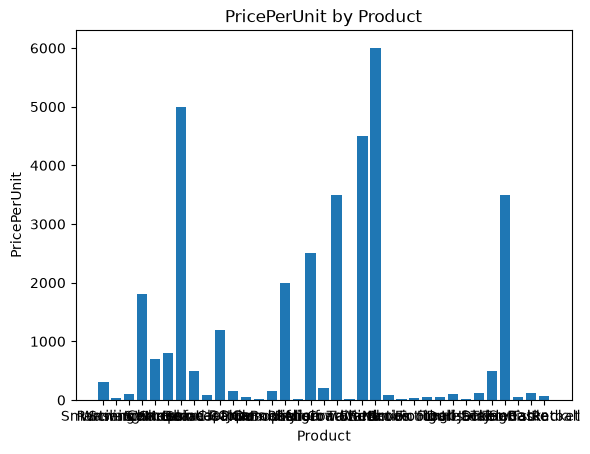

Bar plot displayed successfully!

========== Data Analysis & Visualization Program ==========
Please select an option:
1. Load Dataset
2. Explore Data
3. Perform DataFrame Operations
4. Handle Missing Data
5. Generate Descriptive Statistics
6. Data Visualization
7. Save Visualization
8. Exit



Enter your choice:  7



== Save Visualization ==


Enter file name to save the plot (e.g., scatter_plot.png):  bar_plot.png


Visualization saved as bar_plot.png successfully!

========== Data Analysis & Visualization Program ==========
Please select an option:
1. Load Dataset
2. Explore Data
3. Perform DataFrame Operations
4. Handle Missing Data
5. Generate Descriptive Statistics
6. Data Visualization
7. Save Visualization
8. Exit



Enter your choice:  8



Exiting the program. Goodbye!


In [7]:
if __name__ == "__main__":
    main()